<a href="https://colab.research.google.com/github/lucasbomfim1207-ai/CP_PAI_2/blob/main/CKP02_corrigido_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎲 CKP02 — DocMind RAG · Regras de Monopoly

**Disciplina:** Prompt Engineering and Artificial Intelligence · FIAP · CC 2026  
**Checkpoint 02 — Módulo 2** · Pipeline RAG completo com ChromaDB + RAGAS  

**Integrantes (nome — RM):**
- Julia Johanson Peniche Dias Da Silva - RM: 572220
- Lucas Bomfim Leite - RM: 570420
- Eduardo Barcelos De Carvalho Braziliano - RM: 573274

---

> ▶️ Rode com **Runtime → Run all**. Antes, cadastre o Secret `OLLAMA_API_KEY` no Colab (🔑) e suba os documentos na Seção 2.

## 1. Instalação e configuração dos modelos

In [1]:
!pip install -q langchain langchain-core langchain-community langchain-ollama langchain-chroma langchain-text-splitters chromadb pymupdf sentence-transformers ragas datasets gradio pandas tabulate matplotlib
!pip install -q --force-reinstall -U opentelemetry-api opentelemetry-sdk opentelemetry-semantic-conventions opentelemetry-exporter-otlp-proto-grpc  # repara conflito de versões do opentelemetry (chromadb) no Colab

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3

In [2]:
import os, subprocess, time, requests
from google.colab import userdata
from langchain_ollama import ChatOllama, OllamaEmbeddings

# --- Chave no Colab Secrets (nunca escreva a chave no código) ---
OLLAMA_API_KEY = userdata.get("OLLAMA_API_KEY").strip()      # .strip() remove espaço/quebra de linha
OLLAMA_HOST = "https://ollama.com"
os.environ["OLLAMA_API_KEY"] = OLLAMA_API_KEY
HEADERS = {"Authorization": f"Bearer {OLLAMA_API_KEY}"}

MODELO_CHAT = "gemma4:cloud"           # geração (único aprovado)
MODELO_EMBEDDING = "nomic-embed-text"  # embeddings (único aprovado)
MODELO_JUIZ = "gpt-oss:120b"           # juiz do RAGAS

# --- DIAGNÓSTICO: o que o ollama.com realmente aceita com a sua chave? ---
r = requests.get(f"{OLLAMA_HOST}/api/tags", headers=HEADERS, timeout=30)
print("GET /api/tags ->", r.status_code)
if r.ok:
    print("Modelos na nuvem:", [m["name"] for m in r.json().get("models", [])])
r = requests.post(f"{OLLAMA_HOST}/api/embed", headers=HEADERS, timeout=30,
                  json={"model": MODELO_EMBEDDING, "input": "teste"})
print("POST /api/embed (nuvem) ->", r.status_code, r.text[:150])
EMBED_NA_NUVEM = r.ok


GET /api/tags -> 200
Modelos na nuvem: ['nemotron-3-ultra', 'glm-5.2', 'minimax-m3', 'nemotron-3-super', 'minimax-m2.7', 'mistral-large-3:675b', 'kimi-k2.6', 'kimi-k2.7-code', 'kimi-k3', 'deepseek-v4-pro:0813', 'gpt-oss:120b', 'mistral-large-4', 'gemma4:31b', 'glm-5.3-flash', 'glm-5.3', 'deepseek-v4.1-flash', 'nemotron-3-nano:30b', 'gpt-oss:20b']
POST /api/embed (nuvem) -> 401 {"error": "unauthorized"}


## 2. Base de conhecimento real

Coloque os documentos na pasta `data/` (PDF, TXT ou MD) e **preencha o dicionário `DOCS_META`** com a fonte de cada arquivo.  
O enunciado exige **≥5 documentos reais, com fonte citada** (links de origem). Sugestões de fontes para o domínio Monopoly:
manual oficial do jogo clássico (Hasbro), regras do Banco Imobiliário (Estrela), regras de variantes (Monopoly Deal, Junior etc.), regras de torneio e FAQ oficial.

Os campos de metadata (`tipo`, `categoria`, `data`, `idioma`) alimentam o **filtro por metadata** (diferencial).

In [3]:
import os, pandas as pd
from google.colab import files

PASTA_DOCS = "./data"
os.makedirs(PASTA_DOCS, exist_ok=True)

# Se a pasta estiver vazia, abre o upload do Colab
if not [f for f in os.listdir(PASTA_DOCS) if f.lower().endswith((".pdf", ".txt", ".md"))]:
    print("📂 Envie os documentos da base (PDF/TXT/MD):")
    enviados = files.upload()
    for nome, conteudo in enviados.items():
        with open(os.path.join(PASTA_DOCS, nome), "wb") as f:
            f.write(conteudo)
print("Arquivos em data/:", os.listdir(PASTA_DOCS))

Arquivos em data/: ['doc4.pdf', 'doc5.pdf', 'doc3.pdf', 'doc2.pdf', 'doc1.pdf']


In [4]:
# chave = nome EXATO do arquivo em data/ (antes as chaves eram nomes do site da Hasbro e nunca batiam)
BASE_URL = "https://instructions.hasbro.com/api/download/"
DOCS_META = {
    "doc1.pdf": {
        "titulo": "Regras — Monopoly Junior (FR/EN)", "tipo": "manual",
        "categoria": "variantes", "data": "2017", "idioma": "fr/en",
        "url": BASE_URL + "A6984_pt-br_jogo-monopoly-junior.pdf"},
    "doc2.pdf": {
        "titulo": "Regras — Monopoly Banco Eletrônico", "tipo": "manual",
        "categoria": "variantes", "data": "2013", "idioma": "pt",
        "url": BASE_URL + "A7444_pt-br_jogo-monopoly-banco-eletronico.pdf"},
    "doc3.pdf": {
        "titulo": "Regras — Monopoly Grab and Go", "tipo": "manual",
        "categoria": "variantes", "data": "2014", "idioma": "pt",
        "url": BASE_URL + "B1002_pt-br_jogo-monopoly-grab-go-game.pdf"},
    "doc4.pdf": {
        "titulo": "Regras oficiais — Monopoly Clássico", "tipo": "manual",
        "categoria": "regras_gerais", "data": "2021", "idioma": "pt",
        "url": BASE_URL + "00009_pt-br_monopoly.pdf"},
    "doc5.pdf": {
        "titulo": "Regras — Monopoly Fortnite", "tipo": "manual",
        "categoria": "variantes", "data": "2019", "idioma": "pt",
        "url": BASE_URL + "E6603_pt-br_jogo-monopoly-fortnite.pdf"},
}
META_PADRAO = {"titulo": "sem título", "tipo": "manual", "categoria": "geral",
               "data": "s/d", "idioma": "pt", "url": ""}


In [5]:
from langchain_community.document_loaders import PyMuPDFLoader, TextLoader

def carregar_documentos(pasta: str, meta: dict) -> list:
    """LOAD: lê PDF/TXT/MD da pasta e anexa a metadata de cada arquivo."""
    paginas = []
    for arquivo in sorted(os.listdir(pasta)):
        caminho = os.path.join(pasta, arquivo)
        ext = arquivo.lower().rsplit(".", 1)[-1]
        if ext == "pdf":
            docs = PyMuPDFLoader(caminho).load()
        elif ext in ("txt", "md"):
            docs = TextLoader(caminho, encoding="utf-8").load()
        else:
            continue
        info = meta.get(arquivo)
        if info is None:
            print(f"⚠️ '{arquivo}' não está em DOCS_META — usando metadata padrão.")
            info = META_PADRAO
        for d in docs:
            d.metadata = {**info, "source": arquivo, "page": int(d.metadata.get("page", 0))}
        paginas.extend(docs)
    return paginas

paginas = carregar_documentos(PASTA_DOCS, DOCS_META)

resumo = (pd.DataFrame([d.metadata for d in paginas])
          .groupby(["source", "tipo", "categoria", "url"]).size()
          .reset_index(name="paginas"))
display(resumo)
print(f"Total: {resumo['source'].nunique()} documentos · {len(paginas)} páginas")

# Validações exigidas pelo enunciado
assert resumo["source"].nunique() >= 5, "❌ A base precisa ter ≥5 documentos reais."
assert (resumo["url"].str.startswith("http")).all(), "❌ Há documentos sem url de origem (confira as chaves de DOCS_META = nome do arquivo)."
print("✅ Base de conhecimento válida.")

/tmp/ipykernel_622/2560022928.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader, TextLoader


,source,tipo,categoria,url,paginas
0,doc1.pdf,manual,variantes,https://instructions.hasbro.com/api/download/A...,4
1,doc2.pdf,manual,variantes,https://instructions.hasbro.com/api/download/A...,12
2,doc3.pdf,manual,variantes,https://instructions.hasbro.com/api/download/B...,2
3,doc4.pdf,manual,regras_gerais,https://instructions.hasbro.com/api/download/0...,2
4,doc5.pdf,manual,variantes,https://instructions.hasbro.com/api/download/E...,2


Total: 5 documentos · 22 páginas
✅ Base de conhecimento válida.


## 3. Split — estratégias de chunking

Usamos `RecursiveCharacterTextSplitter` com `separators=["\n\n", "\n", ". ", " ", ""]` (Aula 06) e `chunk_overlap` = **12%** do `chunk_size` (dentro da faixa de 10–15% exigida).  
Comparamos `chunk_size` = **256, 512 e 1024** (as mesmas configurações da demo da Aula 07).

In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

CHUNK_SIZES = [256, 512, 1024]   # ≥2 configurações comparadas
OVERLAP_PCT = 0.12               # 10–15% do chunk_size

def dividir_documentos(paginas: list, chunk_size: int) -> list:
    """SPLIT: divide as páginas em chunks e registra chunk_id/chunk_size na metadata."""
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=int(chunk_size * OVERLAP_PCT),
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    chunks = splitter.split_documents(paginas)
    for i, c in enumerate(chunks):
        c.metadata["chunk_id"] = f"cs{chunk_size}-{i}"
        c.metadata["chunk_size"] = chunk_size
    return chunks

CHUNKS = {cs: dividir_documentos(paginas, cs) for cs in CHUNK_SIZES}
estat = pd.DataFrame([{
    "chunk_size": cs, "overlap": int(cs * OVERLAP_PCT), "n_chunks": len(ch),
    "tamanho_medio_chars": round(sum(len(c.page_content) for c in ch) / len(ch)),
} for cs, ch in CHUNKS.items()])
display(estat)

,chunk_size,overlap,n_chunks,tamanho_medio_chars
0,256,30,315,224
1,512,61,160,458
2,1024,122,85,877


## 4. Embed + Store — ChromaDB local

Uma coleção por configuração de chunking (`monopoly_regras_cs256`, `..._cs512`, ...), todas com `nomic-embed-text`.

In [7]:
import shutil, subprocess, time, os

def sh(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(f"$ {cmd}\n{(r.stdout + r.stderr)[-600:]}")
    return r.returncode

if EMBED_NA_NUVEM:
    EMB_HOST, EMB_KW = OLLAMA_HOST, {"headers": HEADERS}
else:
    if not shutil.which("ollama"):
        sh("apt-get update -qq && apt-get install -y -qq zstd pciutils")
        sh("curl -fsSL https://ollama.com/install.sh | sh")
    assert shutil.which("ollama"), "❌ Ollama não instalou — veja o erro impresso acima."

    env = {k: v for k, v in os.environ.items() if k not in ("OLLAMA_HOST", "OLLAMA_API_KEY")}
    subprocess.Popen(["ollama", "serve"], env=env,
                     stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    time.sleep(10)
    subprocess.run(["ollama", "pull", MODELO_EMBEDDING], env=env, check=True)
    EMB_HOST, EMB_KW = "http://127.0.0.1:11434", {}

embeddings = OllamaEmbeddings(model=MODELO_EMBEDDING, base_url=EMB_HOST, client_kwargs=EMB_KW)
print("dim do embedding:", len(embeddings.embed_query("teste")))   # esperado: 768

llm = ChatOllama(model=MODELO_CHAT, temperature=0, base_url=OLLAMA_HOST,
                 client_kwargs={"headers": HEADERS})

$ apt-get update -qq && apt-get install -y -qq zstd pciutils
mbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_opencl.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_loader.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libumf.so.1 is not a symbolic link

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)

$ curl -fsSL https://ollama.com/install.sh | sh
####################################################   99.7%
#######################################################################   99.9%
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...


In [8]:
import chromadb
from langchain_chroma import Chroma

CHROMA_PATH = "./chroma_db"
COLECAO_BASE = "monopoly_regras"      # coleção com o nome do domínio
cliente_chroma = chromadb.PersistentClient(path=CHROMA_PATH)
VECTORSTORES = {}                      # chunk_size -> Chroma

def construir_indice(chunks: list, chunk_size: int, lote: int = 64) -> Chroma:
    """EMBED + STORE: (re)cria a coleção e indexa os chunks em lotes."""
    nome = f"{COLECAO_BASE}_cs{chunk_size}"
    try:
        cliente_chroma.delete_collection(nome)   # evita duplicar chunks ao reexecutar
    except Exception:
        pass
    vs = Chroma(client=cliente_chroma, collection_name=nome, embedding_function=embeddings)
    for i in range(0, len(chunks), lote):
        vs.add_documents(chunks[i:i + lote])
    print(f"✅ {nome}: {len(chunks)} chunks armazenados")
    return vs

for cs in CHUNK_SIZES:
    VECTORSTORES[cs] = construir_indice(CHUNKS[cs], cs)

# Estado do índice ativo (usado por buscar/responder)
ESTADO = {"chunk_size": 512}
def ativar_indice(chunk_size: int) -> None:
    ESTADO["chunk_size"] = chunk_size
    print(f"Índice ativo: chunk_size={chunk_size}")
ativar_indice(512)

✅ monopoly_regras_cs256: 315 chunks armazenados
✅ monopoly_regras_cs512: 160 chunks armazenados
✅ monopoly_regras_cs1024: 85 chunks armazenados
Índice ativo: chunk_size=512


## 5. Retrieve — `buscar(consulta)` com filtro e reranking

Função **modular** (será a `@tool` do CKP03): busca ampla por similaridade (`k=10`) → *(opcional)* filtro de metadata (`where`) → reranking com cross-encoder → `top_n` chunks.

In [9]:
from typing import List, Optional, Dict, Any
from langchain_core.documents import Document
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")   # leve, roda em CPU

def buscar(consulta: str, k: int = 10, top_n: int = 4,
           filtro: Optional[Dict[str, Any]] = None,
           usar_rerank: bool = True) -> List[Document]:
    """RETRIEVE: retorna os chunks mais relevantes para a consulta.

    filtro: dict de metadata do Chroma, ex.: {"categoria": "variantes"}.
    """
    vs = VECTORSTORES[ESTADO["chunk_size"]]
    candidatos = vs.similarity_search(consulta, k=k, filter=filtro)
    if not candidatos:
        return []
    if not usar_rerank:
        return candidatos[:top_n]
    scores = reranker.predict([[consulta, d.page_content] for d in candidatos])
    ordenados = sorted(zip(candidatos, scores), key=lambda x: x[1], reverse=True)
    resultado = []
    for doc, score in ordenados[:top_n]:
        doc.metadata["rerank_score"] = float(score)
        resultado.append(doc)
    return resultado

# Teste: busca semântica retornando resultado
for d in buscar("Quanto dinheiro cada jogador recebe no início do jogo?", top_n=3):
    print(f"[{d.metadata['source']} · pág. {d.metadata['page'] + 1}] {d.page_content[:130]}...\n")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

[doc4.pdf · pág. 2] conseguir! Quanto mais propriedades comprar, mais 
aluguel receberá dos outros jogadores. O último 
jogador a permanecer com dinhe...

[doc3.pdf · pág. 1] jogador. Os jogadores devem pagar ao 
Banco o valor das propriedades que lhe 
saíram em sorte. Agora inicie o jogo  
da forma habi...

[doc5.pdf · pág. 2] NA PRIMEIRA VEZ QUE JOGARES
PREPARAÇÃO! 
Salta do Ônibus de Batalha!  
Nesta versão de MONOPOLY não começas 
o jogo na CASA DE PAR...



## 6. Generate — resposta fundamentada com citação da fonte

Prompt com XML tagging (como na Aula 07), `temperature=0` e **exclusivamente `gemma4:cloud`**. A resposta cita o chunk de origem.

In [10]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

PROMPT_RAG = """<persona>
Você é o Juiz Oficial de regras de Monopoly: neutro, preciso e didático.
Responda com base EXCLUSIVAMENTE nos documentos fornecidos.
</persona>

<instrucoes>
- Responda SOMENTE com informações do contexto abaixo.
- Sempre cite a fonte ao final de cada afirmação: (fonte: arquivo, pág. X).
- Se a resposta não estiver no contexto, diga exatamente:
  "Não encontrei essa informação nos documentos fornecidos."
- Nunca invente, extrapole ou use conhecimento externo.
- Seja direto; use lista com marcadores para passos de jogadas complexas.
</instrucoes>

<contexto>
{contexto}
</contexto>

<pergunta>
{pergunta}
</pergunta>"""

chain_geracao = ChatPromptTemplate.from_template(PROMPT_RAG) | llm | StrOutputParser()

def formatar_contexto(docs: List[Document]) -> str:
    return "\n\n---\n\n".join(
        f"[Chunk {i} · fonte: {d.metadata['source']}, pág. {d.metadata['page'] + 1}]\n{d.page_content}"
        for i, d in enumerate(docs, 1))

def responder(pergunta: str, filtro: Optional[dict] = None, **kwargs) -> Dict[str, Any]:
    """Pipeline completo: retrieve → generate. Retorna resposta, fontes e contextos."""
    docs = buscar(pergunta, filtro=filtro, **kwargs)
    if not docs:
        msg = "Não encontrei essa informação nos documentos fornecidos."
        return {"resposta": msg, "resposta_formatada": msg, "fontes": [], "contextos": []}
    resposta = chain_geracao.invoke({"contexto": formatar_contexto(docs), "pergunta": pergunta})
    fontes = sorted({(d.metadata["source"], d.metadata["page"] + 1, d.metadata["chunk_id"]) for d in docs})
    lista = "\n".join(f"- {s} (pág. {p}) · {cid}" for s, p, cid in fontes)
    return {"resposta": resposta,                                   # usada no RAGAS
            "resposta_formatada": f"{resposta}\n\n**Fontes consultadas:**\n{lista}",
            "fontes": fontes,
            "contextos": [d.page_content for d in docs]}

r = responder("O que acontece quando o jogador cai na casa 'Vá para a Prisão'?")
print(r["resposta_formatada"])

Quando o jogador para no espaço "Vá Para a Prisão", ocorre o seguinte:

*   O jogador deve mover de imediato o seu peão para a Prisão (fonte: doc2.pdf, pág. 8; doc3.pdf, pág. 1).
*   O jogador não recebe A200 por passar pela CASA DE PARTIDA (fonte: doc2.pdf, pág. 8; doc3.pdf, pág. 1).
*   A jogada do jogador termina (fonte: doc2.pdf, pág. 8).

**Fontes consultadas:**
- doc2.pdf (pág. 8) · cs512-57
- doc3.pdf (pág. 1) · cs512-78
- doc3.pdf (pág. 1) · cs512-86
- doc3.pdf (pág. 1) · cs512-87


## 7. Diferencial — Metadata filtering (`where`)

Restringe a busca por `categoria`/`tipo` definidos na Seção 2.

In [11]:
pergunta = "Como funcionam as regras do jogo?"
for filtro in [None, {"categoria": "regras_gerais"}, {"categoria": "variantes"},
               {"$and": [{"tipo": "manual"}, {"categoria": "variantes"}]}]:
    docs = buscar(pergunta, filtro=filtro, top_n=3)
    print(f"\nfiltro = {filtro}")
    for d in docs:
        print(f"  → {d.metadata['source']} | categoria={d.metadata['categoria']} | tipo={d.metadata['tipo']}")


filtro = None
  → doc2.pdf | categoria=variantes | tipo=manual
  → doc5.pdf | categoria=variantes | tipo=manual
  → doc5.pdf | categoria=variantes | tipo=manual

filtro = {'categoria': 'regras_gerais'}
  → doc4.pdf | categoria=regras_gerais | tipo=manual
  → doc4.pdf | categoria=regras_gerais | tipo=manual
  → doc4.pdf | categoria=regras_gerais | tipo=manual

filtro = {'categoria': 'variantes'}
  → doc2.pdf | categoria=variantes | tipo=manual
  → doc5.pdf | categoria=variantes | tipo=manual
  → doc5.pdf | categoria=variantes | tipo=manual

filtro = {'$and': [{'tipo': 'manual'}, {'categoria': 'variantes'}]}
  → doc2.pdf | categoria=variantes | tipo=manual
  → doc5.pdf | categoria=variantes | tipo=manual
  → doc5.pdf | categoria=variantes | tipo=manual


## 8. Diferencial — Reranking (com × sem cross-encoder)

In [12]:
for q in ["Como funciona o leilão de uma propriedade?",
          "Quantas casas preciso para construir um hotel?"]:
    print(f"\n❓ {q}")
    print("── SEM reranking (distância cosseno):")
    for d in buscar(q, usar_rerank=False, top_n=3):
        print(f"   {d.metadata['source']} p.{d.metadata['page']+1}: {d.page_content[:80]!r}")
    print("── COM reranking (cross-encoder):")
    for d in buscar(q, usar_rerank=True, top_n=3):
        print(f"   {d.metadata['source']} p.{d.metadata['page']+1} (score {d.metadata['rerank_score']:.2f}): {d.page_content[:80]!r}")


❓ Como funciona o leilão de uma propriedade?
── SEM reranking (distância cosseno):
   doc4.pdf p.2: 'em cada um deles.\nESPAÇOS DO TABULEIRO\nPROPRIEDADES\nExistem três tipos de propri'
   doc3.pdf p.2: 'à sua frente. Pode começar a receber \nrendas de todos os jogadores que \npararem '
   doc2.pdf p.7: 'Renda com \nA9.25M\nRenda com \nA11M\nPreço das Casas \nA1.5M\nPreço do Hotel \nA1.5M\n '
── COM reranking (cross-encoder):
   doc2.pdf p.9 (score 3.27): 'propriedade para leilão, também podem \nparticipar).\n3. \x07O jogador com a melhor o'
   doc4.pdf p.2 (score 3.22): 'em cada um deles.\nESPAÇOS DO TABULEIRO\nPROPRIEDADES\nExistem três tipos de propri'
   doc2.pdf p.9 (score 2.73): 'devolva os seus edifícios ao banco.\nNão pode construir edifícios numa Rua, se um'

❓ Quantas casas preciso para construir um hotel?
── SEM reranking (distância cosseno):
   doc4.pdf p.1: 'Acabaram as construções?\nNão é possível comprar mais até que um jogador\x03 venda a'
   doc2.pdf p.9: 'pagar para 

## 9. Avaliação com RAGAS — faithfulness + answer_relevancy

**≥5 perguntas** testadas para **cada** configuração de chunking.  
⚠️ As perguntas abaixo são exemplos do jogo clássico: **confira se cada uma tem resposta nos SEUS documentos** e ajuste. Uma pergunta fora da base (última) testa se o sistema recusa em vez de alucinar.

In [13]:
PERGUNTAS = [
    "Quanto dinheiro cada jogador recebe no início do jogo?",
    "O que acontece quando um jogador cai na casa 'Vá para a Prisão'?",
    "Como funciona o leilão quando o jogador não quer comprar a propriedade?",
    "Quantas casas são necessárias antes de construir um hotel?",
    "Como hipotecar uma propriedade e quanto o jogador recebe?",
    "Quanto o jogador recebe ao passar pelo ponto de partida?",
    "Qual é a cor oficial do tabuleiro de xadrez do Monopoly?",   # fora da base → deve recusar
]

In [14]:
# Compatibilidade: o ragas importa módulos Vertex AI removidos do langchain-community 0.4.
import sys, types
class _Vazio: pass
try:
    import langchain_community.chat_models.vertexai
except ImportError:
    _m = types.ModuleType("langchain_community.chat_models.vertexai"); _m.ChatVertexAI = _Vazio
    sys.modules["langchain_community.chat_models.vertexai"] = _m
import langchain_community.llms as _llms
if not hasattr(_llms, "VertexAI"): _llms.VertexAI = _Vazio

In [15]:
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.run_config import RunConfig
from datasets import Dataset

ragas_llm = LangchainLLMWrapper(ChatOllama(model=MODELO_JUIZ, temperature=0, base_url=OLLAMA_HOST,
                                           client_kwargs={"headers": HEADERS}))
ragas_embs = LangchainEmbeddingsWrapper(embeddings)

def faithfulness_manual(resposta: str, contexto: str) -> float:
    """Fallback (Aula 07, slide 14): LLM-as-judge se o pacote RAGAS falhar."""
    prompt = ChatPromptTemplate.from_template(
        "<tarefa>Avalie se a RESPOSTA está fundamentada no CONTEXTO.</tarefa>\n"
        "<contexto>{contexto}</contexto>\n<resposta>{resposta}</resposta>\n"
        "Responda APENAS com um número de 0 a 1 (1.0 = toda a resposta está no contexto; 0.0 = inventa).")
    juiz = ChatOllama(model=MODELO_JUIZ, temperature=0, base_url=OLLAMA_HOST, client_kwargs={"headers": HEADERS})
    try:
        return float((prompt | juiz | StrOutputParser()).invoke({"contexto": contexto, "resposta": resposta}).strip())
    except ValueError:
        return -1.0   # sentinela: score inválido

def avaliar_configuracao(chunk_size: int, perguntas: list, usar_rerank: bool = True) -> pd.DataFrame:
    """Roda o pipeline com um chunk_size e devolve faithfulness/answer_relevancy por pergunta."""
    ativar_indice(chunk_size)
    dados = {"question": [], "answer": [], "contexts": []}
    for q in perguntas:
        r = responder(q, usar_rerank=usar_rerank)
        dados["question"].append(q)
        dados["answer"].append(r["resposta"])
        dados["contexts"].append(r["contextos"] or [""])
    try:
        res = evaluate(Dataset.from_dict(dados), metrics=[faithfulness, answer_relevancy],
                       llm=ragas_llm, embeddings=ragas_embs,
                       run_config=RunConfig(timeout=300, max_workers=2))
        m = res.to_pandas()
        faith, rel = m["faithfulness"].values, m["answer_relevancy"].values
    except Exception as e:
        print(f"⚠️ RAGAS falhou ({type(e).__name__}: {e}). Usando faithfulness manual.")
        faith = [faithfulness_manual(a, "\n".join(c)) for a, c in zip(dados["answer"], dados["contexts"])]
        rel = [float("nan")] * len(perguntas)
    return pd.DataFrame({"chunk_size": chunk_size, "pergunta": perguntas,
                         "faithfulness": faith, "answer_relevancy": rel})

resultados = pd.concat([avaliar_configuracao(cs, PERGUNTAS) for cs in CHUNK_SIZES], ignore_index=True)
resultados.to_csv("resultados_ragas.csv", index=False)

/tmp/ipykernel_622/686094388.py:2: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy
/tmp/ipykernel_622/686094388.py:2: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy
/tmp/ipykernel_622/686094388.py:8: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  ragas_llm = LangchainLLMWrapper(ChatOllama(model=MODELO_JUIZ, temperature=0, base_url=OLLAM

Índice ativo: chunk_size=256


Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Índice ativo: chunk_size=512


Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

Índice ativo: chunk_size=1024


Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]

In [16]:
# Tabela por pergunta × configuração
pd.set_option("display.max_colwidth", 60)
display(resultados.pivot_table(index="pergunta", columns="chunk_size",
                               values=["faithfulness", "answer_relevancy"]).round(3))

# Médias por configuração
medias = resultados.groupby("chunk_size")[["faithfulness", "answer_relevancy"]].mean().round(3)
medias["aprovado (faith ≥ 0,7)"] = medias["faithfulness"] >= 0.7
display(medias)

answer_relevancy  \
chunk_size                                                               256    
pergunta                                                                        
Como funciona o leilão quando o jogador não quer comprar ...            0.969   
Como hipotecar uma propriedade e quanto o jogador recebe?               0.000   
O que acontece quando um jogador cai na casa 'Vá para a P...            0.971   
Qual é a cor oficial do tabuleiro de xadrez do Monopoly?                0.600   
Quantas casas são necessárias antes de construir um hotel?              0.825   
Quanto dinheiro cada jogador recebe no início do jogo?                  0.538   
Quanto o jogador recebe ao passar pelo ponto de partida?                0.940   

                                                                            \
chunk_size                                                     512    1024   
pergunta                                                                     
Como funciona o leilão quando o jogador não quer comprar ...  0.967  0.599   
Como hipotecar uma propriedade e quanto o jogador recebe?     0.000  0.809   
O que acontece quando um jogador cai na casa 'Vá para a P...  0.995  0.560   
Qual é a cor oficial do tabuleiro de xadrez do Monopoly?      0.000  0.000   
Quantas casas são necessárias antes de construir um hotel?    0.990  0.928   
Quanto dinheiro cada jogador recebe no início do jogo?        0.000  0.491   
Quanto o jogador recebe ao passar pelo ponto de partida?      0.603  0.889   

                                                             faithfulness  \
chunk_size                                                           256    
pergunta                                                                    
Como funciona o leilão quando o jogador não quer comprar ...        0.400   
Como hipotecar uma propriedade e quanto o jogador recebe?           0.000   
O que acontece quando um jogador cai na casa 'Vá para a P...        1.000   
Qual é a cor oficial do tabuleiro de xadrez do Monopoly?            0.000   
Quantas casas são necessárias antes de construir um hotel?          0.333   
Quanto dinheiro cada jogador recebe no início do jogo?              1.000   
Quanto o jogador recebe ao passar pelo ponto de partida?            0.000   

                                                                          
chunk_size                                                   512    1024  
pergunta                                                                  
Como funciona o leilão quando o jogador não quer comprar ...  1.0  1.000  
Como hipotecar uma propriedade e quanto o jogador recebe?     0.0  1.000  
O que acontece quando um jogador cai na casa 'Vá para a P...  1.0  1.000  
Qual é a cor oficial do tabuleiro de xadrez do Monopoly?      0.0  1.000  
Quantas casas são necessárias antes de construir um hotel?    1.0  0.333  
Quanto dinheiro cada jogador recebe no início do jogo?        1.0  1.000  
Quanto o jogador recebe ao passar pelo ponto de partida?      0.5  0.500

,faithfulness,answer_relevancy,"aprovado (faith ≥ 0,7)"
chunk_size,,,
256,0.390,0.692,False
512,0.643,0.508,False
1024,0.833,0.611,True


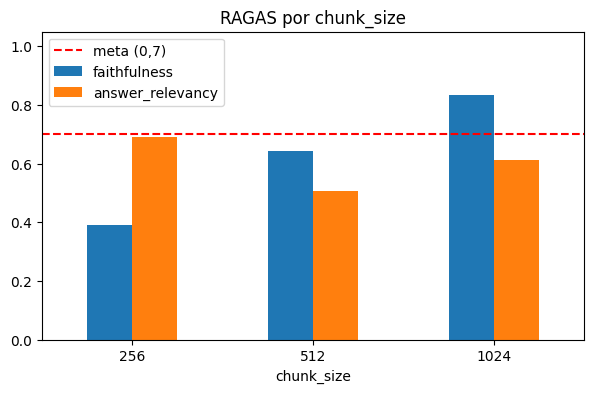

In [17]:
import matplotlib.pyplot as plt
ax = medias[["faithfulness", "answer_relevancy"]].plot(kind="bar", figsize=(7, 4), rot=0)
ax.axhline(0.7, color="red", ls="--", label="meta (0,7)")
ax.set_title("RAGAS por chunk_size"); ax.set_ylim(0, 1.05); ax.legend(); plt.show()

## 10. Conclusão — qual chunking ganhou e por quê?

A célula abaixo escolhe o vencedor **pelos dados** (maior faithfulness média; desempate por answer_relevancy).  
Depois, **escreva a justificativa** com base nos números e no diagnóstico (Aula 07, Exercício 4):
- trecho PRESENTE no contexto + resposta errada → problema de prompt/LLM;
- trecho AUSENTE do contexto → problema de retrieval (ajustar `chunk_size`/overlap/`k`).

In [18]:
vencedor = int(medias.sort_values(["faithfulness", "answer_relevancy"], ascending=False).index[0])
print(f"🏆 Melhor configuração: chunk_size={vencedor}")
print(medias.loc[vencedor].to_string())
if medias.loc[vencedor, "faithfulness"] < 0.7:
    print("⚠️ Faithfulness < 0,7 — itere no chunking/prompt/k antes de entregar.")
if medias.loc[vencedor, "faithfulness"] < 0.5:
    print("🚨 Faithfulness < 0,5 indica alucinação significativa.")

# Pior caso para diagnóstico
pior = resultados[resultados.chunk_size == vencedor].sort_values("faithfulness").iloc[0]
print(f"\nPior pergunta: {pior['pergunta']} (faith={pior['faithfulness']:.2f})")
ativar_indice(vencedor)
for i, d in enumerate(buscar(pior["pergunta"]), 1):
    print(f"[chunk {i}] {d.metadata['source']} p.{d.metadata['page']+1}: {d.page_content[:150]!r}")

🏆 Melhor configuração: chunk_size=1024
faithfulness              0.833
answer_relevancy          0.611
aprovado (faith ≥ 0,7)     True

Pior pergunta: Quantas casas são necessárias antes de construir um hotel? (faith=0.33)
Índice ativo: chunk_size=1024
[chunk 1] doc2.pdf p.9: '8\nCasas\nQuando conseguir juntar um grupo de \ncor, pode começar a comprar Casas; \nnão precisa de esperar pela sua vez \nde jogar.\nPague ao Banco o valor'
[chunk 2] doc3.pdf p.2: 'tal, mas não pode construir nada se uma \ndas propriedades do grupo de cor \nestiver hipotecada.\nCONSTRUIR EDIFÍCIOS \nQuando tiver quatro Casas\xa0 \nem cad'
[chunk 3] doc4.pdf p.1: 'construir no máximo quatro casas em cada propriedade. \nHá apenas uma construção  \ndisponível no Banco?\nSe mais de um jogador quiser comprar o último h'
[chunk 4] doc4.pdf p.1: 'construções entre si.\nPropriedades podem ser \ntrocadas por dinheiro, por \noutras propriedades ou por \ncartas Está Livre da Prisão. \nA quantia será dec'


### ✍️ Justificativa do grupo *(preencher após rodar)*

> O chunk_size **___** obteve faithfulness média de **___** e answer_relevancy de **___**, contra ___ e ___ das demais configurações.  
> Isso acontece porque ___ (ex.: chunks menores aumentam a precisão do match, mas fragmentam regras com várias condições; chunks maiores trazem mais contexto, mas diluem o embedding e podem incluir ruído).  
> O reranking ___ (melhorou / não alterou) os resultados porque ___.  
> A pergunta fora da base foi ___ (recusada corretamente / alucinada).

## 11. Função final para o CKP03 (`@tool`)

Com o índice vencedor ativo, `buscar(consulta)` já está pronta para virar ferramenta do agente.

In [19]:
from langchain_core.tools import tool

ativar_indice(vencedor)

@tool
def buscar_regras_monopoly(consulta: str) -> str:
    """Busca nas regras oficiais de Monopoly e devolve os trechos relevantes com a fonte."""
    docs = buscar(consulta)
    return formatar_contexto(docs) if docs else "Nenhum trecho relevante encontrado."

print(buscar_regras_monopoly.invoke({"consulta": "Como funciona a hipoteca?"})[:600])

Índice ativo: chunk_size=1024
[Chunk 1 · fonte: doc4.pdf, pág. 1]
Dê a ele todas as suas cartas Saia da Prisão de  
Graça e todas as suas propriedades hipotecadas.
O novo dono deve imediatamente:
Pagar a hipoteca  (pagar o custo para quitar  
a hipoteca ao Banco).
Ou deixar a propriedade hipotecada e pagar  
ao Banco 10% do valor da hipoteca.
Deve dinheiro ao Banco?
Devolva todas as suas propriedades ao  
Banco. Todas as hipotecas são 
canceladas.
Todas as propriedades  
são colocadas imediatamente  
em leilão.
Devolva suas cartas Saia da 
Prisão de Graça à pilha de  
cartas correspondente.
O jogo continua  
até sobrar ape


## 12. Diferencial — Interface Gradio

In [20]:
import gradio as gr

CATEGORIAS = ["(todas)"] + sorted({d.metadata["categoria"] for d in paginas})

def chat_fn(mensagem, historico, categoria):
    filtro = None if categoria == "(todas)" else {"categoria": categoria}
    return responder(mensagem, filtro=filtro)["resposta_formatada"]

demo = gr.ChatInterface(
    fn=chat_fn,
    additional_inputs=[gr.Dropdown(CATEGORIAS, value="(todas)", label="Filtrar por categoria (metadata)")],
    title="🤖 DocMind RAG - Regras de Monopoly",
    description=f"Respostas fundamentadas nos documentos da base (chunk_size={vencedor}) com fonte citada.",
)

# --- CORREÇÃO: o RAGAS aplica nest_asyncio, que troca asyncio.run por uma versão
# sem o argumento `loop_factory`. O uvicorn (usado pelo Gradio) chama
# asyncio.run(..., loop_factory=...) -> TypeError, e o Gradio acaba mostrando
# o erro falso "Cannot find empty port". Restauramos o asyncio.run original:
import asyncio, asyncio.runners
asyncio.run = asyncio.runners.run

# Fecha TODAS as instâncias ativas do Gradio no ambiente
gr.close_all()

# Inicia a interface
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5f368736564a50b1a2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 13. README.md (obrigatório)

In [21]:
readme = f"""# DocMind RAG — Regras de Monopoly (CKP02)

FIAP · Prompt Engineering and Artificial Intelligence · CC 2026 · Prof. Jorge Luiz Gomes

## Integrantes
| Nome | RM |
|---|---|
| Nome 1 (líder) | 00000 |
| Nome 2 | 00000 |
| Nome 3 | 00000 |

## O que é
Pipeline RAG (load → split → embed → store → retrieve → generate) sobre regras de Monopoly.
- Embeddings: `nomic-embed-text` (Ollama Cloud) · Chat: `gemma4:cloud` (temperature=0)
- Vector store: ChromaDB local (coleção `{COLECAO_BASE}_cs<chunk_size>`)
- Chunking comparado: {CHUNK_SIZES} (overlap {int(OVERLAP_PCT*100)}%) · Melhor: **{vencedor}**
- Diferenciais: filtro por metadata, reranking (cross-encoder/ms-marco-MiniLM-L-6-v2), interface Gradio

## Como executar
1. Abra o notebook no Google Colab e cadastre o Secret `OLLAMA_API_KEY`.
2. Coloque os documentos em `data/` (ou envie quando solicitado na Seção 2).
3. Runtime → Run all.

## Como adicionar novos documentos à base
1. Copie o arquivo (PDF, TXT ou MD) para a pasta `data/`.
2. Em `DOCS_META` (Seção 2), adicione uma entrada com o nome do arquivo: `titulo`, `tipo`, `categoria`, `data`, `idioma` e `url` de origem.
3. Rode novamente as Seções 2 a 4 (recarrega, divide e reindexa; as coleções antigas são recriadas, sem duplicar).
4. Rode a Seção 9 para reavaliar o RAGAS com a nova base.

## Resultados RAGAS (média)
{medias.drop(columns=[c for c in medias.columns if 'aprovado' in c]).to_markdown()}

## Fontes dos documentos
""" + "\n".join(f"- {s}: {u}" for s, u in resumo[["source", "url"]].values) + "\n"

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)
print(readme)

# DocMind RAG — Regras de Monopoly (CKP02)

FIAP · Prompt Engineering and Artificial Intelligence · CC 2026 · Prof. Jorge Luiz Gomes

## Integrantes
| Nome | RM |
|---|---|
| Nome 1 (líder) | 00000 |
| Nome 2 | 00000 |
| Nome 3 | 00000 |

## O que é
Pipeline RAG (load → split → embed → store → retrieve → generate) sobre regras de Monopoly.
- Embeddings: `nomic-embed-text` (Ollama Cloud) · Chat: `gemma4:cloud` (temperature=0)
- Vector store: ChromaDB local (coleção `monopoly_regras_cs<chunk_size>`)
- Chunking comparado: [256, 512, 1024] (overlap 12%) · Melhor: **1024**
- Diferenciais: filtro por metadata, reranking (cross-encoder/ms-marco-MiniLM-L-6-v2), interface Gradio

## Como executar
1. Abra o notebook no Google Colab e cadastre o Secret `OLLAMA_API_KEY`.
2. Coloque os documentos em `data/` (ou envie quando solicitado na Seção 2).
3. Runtime → Run all.

## Como adicionar novos documentos à base
1. Copie o arquivo (PDF, TXT ou MD) para a pasta `data/`.
2. Em `DOCS_META` (Seção 2), a